In [1]:
import matplotlib.pyplot as plt
import numpy as np
from csv import reader
from math import sqrt
from math import log
from random import sample
from scipy.optimize import brentq
from scipy.optimize import minimize

selection: list = []
selection_len: int = 0

with open('var_8_loglaplace.csv', mode ='r')as file:
    csvFile = reader(file)
    for lines in csvFile:
        selection.append(float(lines[0]))
        selection_len += 1

Сумма элементов выборки:

In [2]:
def my_sum(array: list) -> float:
    summa: int = 0
    for elem in selection:
        summa += elem
    return round(summa, 2)

In [3]:
my_sum(selection)

-667.93

Выборочное среднее:

In [4]:
def mid(selection: list) -> float:
    summa: int = my_sum(selection)
    return round(summa / selection_len, 2)

In [5]:
mid(selection)

-2.23

Медиана:

In [6]:
def median(selection: list) -> float:
    sorted_selection: list = sorted(selection)
    if selection_len % 2 == 0:
        half: int = int(selection_len / 2)
        return round((sorted_selection[half] + sorted_selection[half + 1]) / 2, 2)
    else:
        return round(sorted_selection[half], 2)

In [7]:
median(selection)

-2.27

Мода:

In [8]:
def moda(selection: list) -> float:
    freq_dict = {}
    for elem in selection:
        freq_dict[elem] = freq_dict.get(elem, 0) + 1
        
    max_freq: int = max(freq_dict.values())

    if(max_freq == 1):
        return None
    
    for key, value in freq_dict.items():
        if value == max_freq:
            return key

In [9]:
print(moda(selection))

None


Размах выборки:

In [10]:
def razmah(selection: list) -> float:
    return round(max(selection) - min(selection), 2)

In [11]:
razmah(selection)

2.24

Смещенная дисперсия:

In [12]:
def smesh_dispersion(selection: list) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return round(summa / selection_len, 2)

In [13]:
smesh_dispersion(selection)

0.11

Несмещенная дисперсия:

In [14]:
def nesmesh_dispersion(selection: list) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return round(summa / (selection_len - 1), 2)

In [15]:
nesmesh_dispersion(selection)

0.11

Выборочный начальный элемент:

In [16]:
def choose_first_elem(selection: list, k: int) -> float:
    summa: float = 0
    for elem in selection:
        summa += elem ** k
    return round(summa / selection_len, 2)

In [17]:
choose_first_elem(selection, 3)

-11.75

Выборочный центральный элемент:

In [18]:
def choose_center_elem(selection: list, k: int) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** k
    return round(sqrt(summa / selection_len), 2)

In [19]:
choose_center_elem(selection, 6)

0.31

Эмперическая функция распределения:

In [20]:
def ecdf(selection: list, count: int):
    sorted_selection = sorted(selection)

    x = []
    y = []

    for i in range(count):
        x.append(sorted_selection[i])
        y.append((i + 1) / count)

    return x, y

График эмперической функции:

In [21]:
def show_graphic_ecdf(x: list, y: list, count: int = -1):
    plt.figure()
    plt.step(x, y, where='post', label="Эмперическая функция")
    plt.scatter(x, y, label="Точки выборки")
    
    plt.xlabel('x')
    plt.ylabel('F*(x)')
    if(count == -1):
        plt.title(f'Эмперическая функция распределения')
    else:
        plt.title(f'Эмперическая функция распределения для выборки из {count} элементов')
    plt.legend()
    plt.grid()
    
    plt.show()

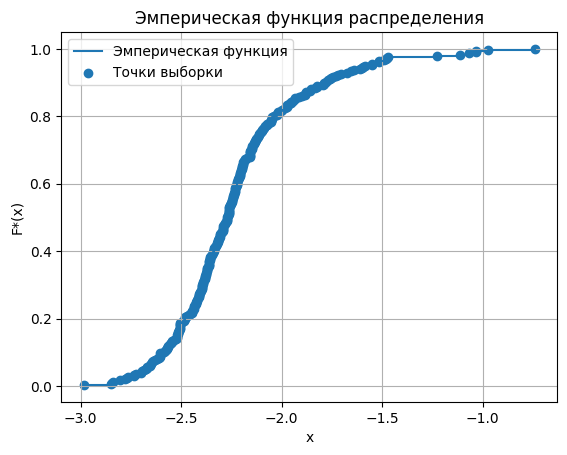

In [22]:
x, y = ecdf(selection, selection_len)
show_graphic_ecdf(x, y)

График эмперичиской функции для 10 случайных элементов:

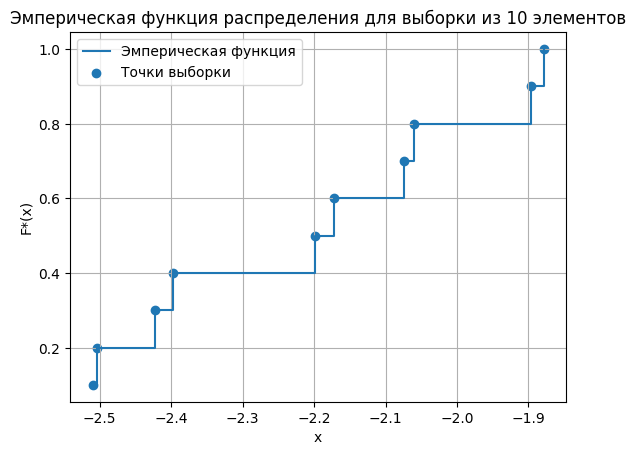

In [23]:
selection_10 = sample(selection, 10)
x, y = ecdf(selection_10, 10)
show_graphic_ecdf(x, y, 10)

График эмперической функции для 100 случайных элементов:

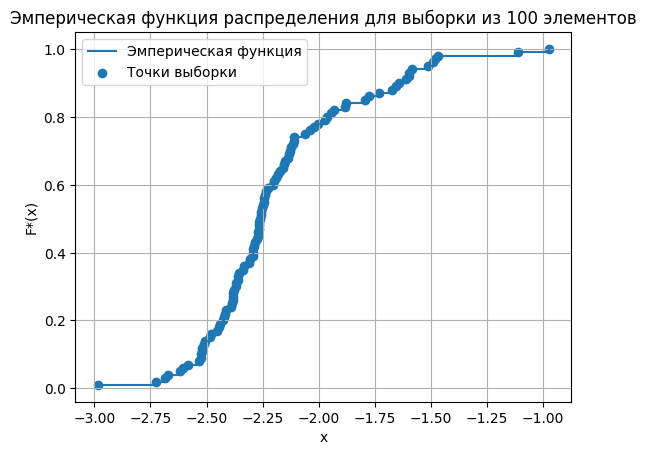

In [24]:
selection_100 = sample(selection, 100)
x, y = ecdf(selection_100, 100)
show_graphic_ecdf(x, y, 100)

График эмперичиской функции для 200 случайных элементов:

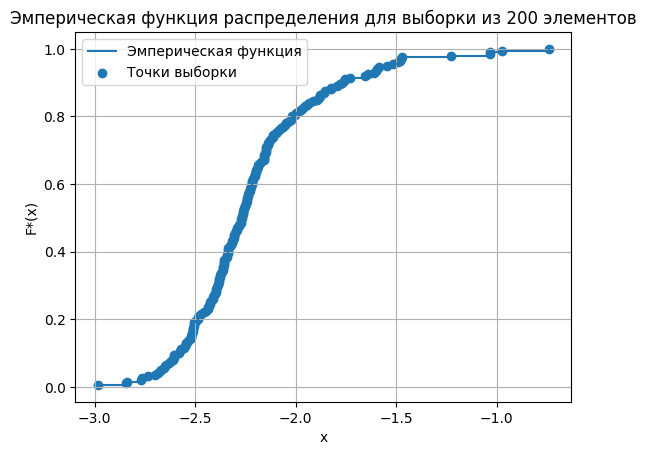

In [25]:
selection_200 = sample(selection, 200)
x, y = ecdf(selection_200, 200)
show_graphic_ecdf(x, y, 200)

In [26]:
def histogram(selection: list, bins=10):
    min_val = min(selection)
    max_val = max(selection)

    bin_width: float = (max_val - min_val) / bins

    edges = [min_val + i * bin_width for i in range(bins + 1)]

    counts = [0] * bins

    for elem in selection:
        for i in range(bins):
            if(edges[i] <= elem < edges[i+1]):
                counts[i] += 1
                break
        else:
            counts[-1] += 1

    return edges, counts

Гистограмма:

In [27]:
def show_histogram(edges: list, counts: list, vyborka: int = -1):
    centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
    
    plt.figure()
    
    plt.bar(centers, counts, width=(edges[1] - edges[0]), alpha=0.6, label="Гистограмма")
    
    plt.plot(centers, counts, marker='o', label="График частот"),

    if(vyborka == -1):
        plt.title("Гистограмма")
    else:
        plt.title(f"Гистограмма для выборки из {vyborka} элементов")
    
    plt.xlabel("Значения")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid()
    
    plt.show()

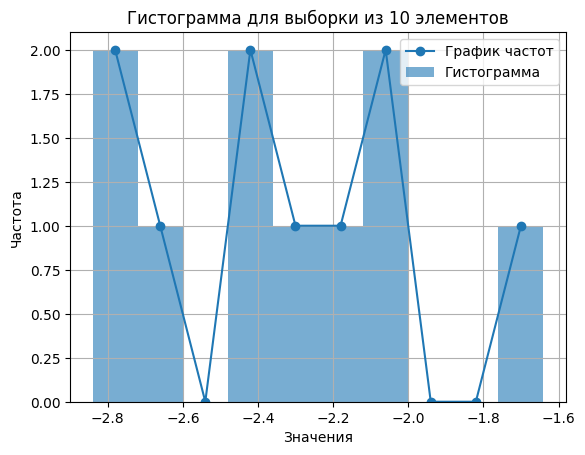

In [28]:
selection_10 = sample(selection, 10)
edges, counts = histogram(selection_10, 10)
show_histogram(edges, counts, 10)

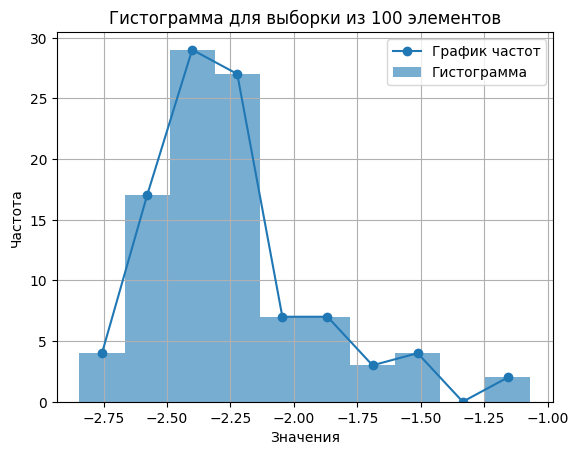

In [29]:
selection_100 = sample(selection, 100)
edges, counts = histogram(selection_100)
show_histogram(edges, counts, 100)

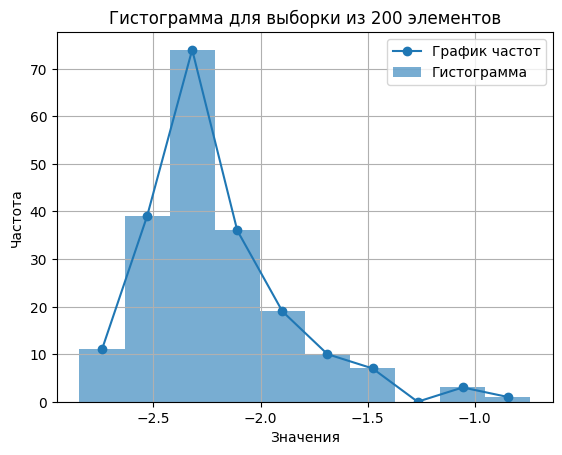

In [30]:
selection_200 = sample(selection, 200)
edges, counts = histogram(selection_200)
show_histogram(edges, counts, 200)

Параметры loc и a по методу моментов:

In [31]:
def theoretical_mean_no_loc(c):
    """E[X] без сдвига, требует c > 1"""
    return c**2 / (c**2 - 1)

def theoretical_variance(c):
    """D[X] не зависит от loc, требует c > 2"""
    ex  = c**2 / (c**2 - 1)
    ex2 = c**2 / (c**2 - 4)
    return ex2 - ex**2


# ── Метод моментов ───────────────────────────────────────────────────────────

def find_loc_a_moment(selection):
    """
    Система уравнений метода моментов:
    
      (1)  s² = D[X](c)          -> находим c
      (2)  x̄  = E[X](c) + loc   -> находим loc = x̄ - E[X](c)
    
    Возвращает (c_hat, loc_hat)
    """
    x_bar = mid(selection)
    s2    = smesh_dispersion(selection)

    # Шаг 1: решаем D[X](c) = s² относительно c
    # D[X](c) убывает по c, при c->2+ уходит в +inf, при c->inf -> 0
    def equation(c):
        return theoretical_variance(c) - s2

    c_hat = brentq(equation, 2.001, 10000.0, xtol=1e-12)

    # Шаг 2: loc = x̄ - E[X](c)
    loc_hat = x_bar - theoretical_mean_no_loc(c_hat)

    return round(c_hat, 2), round(loc_hat, 2)

In [32]:
find_loc_a_moment(selection)

(4.92, -3.27)

Параметры loc и a по методу максимального правдоподобия:

In [33]:
class Point:
    def __init__(self, a: float = 0, loc: float = 0):
        self.a = a
        self.loc = loc

    def get_dist(self, other):
        return sqrt((self.a - other.a) ** 2 + (self.loc - other.loc) ** 2)

    a: float
    loc: float


def find_mid(a: Point, b: Point) -> Point:
    return Point((a.a + b.a) / 2, (a.loc + b.loc) / 2)


def find_new(a: Point, b: Point, c: Point) -> Point:
    mid_point: Point = find_mid(a, b)
    return Point(2 * mid_point.a - c.a, 2 * mid_point.loc - c.loc)


def func_pravdopodobie(selection: list, p: Point) -> float:
    sum_val: float = 0
    for elem in selection:
        fxi: float = 0
        if elem - p.loc <= 0:
            return float("-inf")
        elif elem - p.loc <= 1:
            fxi = log(p.a / 2) + (p.a - 1) * log(elem - p.loc)
        else:
            fxi = log(p.a / 2) - (p.a + 1) * log(elem - p.loc)

        sum_val += fxi

    return sum_val


def find_loc_a_max_prav(selection: list) -> list:
    a, loc = find_loc_a_moment(selection)
    point_1 = Point(a, loc + 0.1)
    point_2 = Point(a, loc)
    point_3 = Point(a + 1, loc)

    for _ in range(100000):
        fp1 = func_pravdopodobie(selection, point_1)
        fp2 = func_pravdopodobie(selection, point_2)
        fp3 = func_pravdopodobie(selection, point_3)

        # Условие остановки
        if (point_1.get_dist(point_2) < 0.00001
            and point_2.get_dist(point_3) < 0.00001
            and point_1.get_dist(point_3) < 0.00001):
            break

        # Находим худшую точку
        min_fp = min(fp1, fp2, fp3)

        if min_fp == fp1:
            worst, p2, p3, fw, f2, f3 = point_1, point_2, point_3, fp1, fp2, fp3
        elif min_fp == fp2:
            worst, p2, p3, fw, f2, f3 = point_2, point_1, point_3, fp2, fp1, fp3
        else:
            worst, p2, p3, fw, f2, f3 = point_3, point_1, point_2, fp3, fp1, fp2

        # Отражаем худшую через середину противоположного ребра
        new_point = find_new(p2, p3, worst)
        fp_new = func_pravdopodobie(selection, new_point)

        if fp_new > fw:
            # Отражение улучшило — заменяем худшую
            if min_fp == fp1:
                point_1 = new_point
            elif min_fp == fp2:
                point_2 = new_point
            else:
                point_3 = new_point
        else:
            # Отражение не помогло — сжимаем к лучшей
            max_fp = max(fp1, fp2, fp3)
            if max_fp == fp1:
                best = point_1
            elif max_fp == fp2:
                best = point_2
            else:
                best = point_3

            point_1 = find_mid(best, point_1)
            point_2 = find_mid(best, point_2)
            point_3 = find_mid(best, point_3)

    fp1 = func_pravdopodobie(selection, point_1)
    fp2 = func_pravdopodobie(selection, point_2)
    fp3 = func_pravdopodobie(selection, point_3)
    max_fp = max(fp1, fp2, fp3)
    if max_fp == fp1:
        return [round(point_1.a, 2), round(point_1.loc, 2)]
    elif max_fp == fp2:
        return [round(point_2.a, 2), round(point_2.loc, 2)]
    else:
        return [round(point_3.a, 2), round(point_3.loc, 2)]


In [34]:
find_loc_a_max_prav(selection)

[4.33, -3.27]

График теоретической функции распределения:

In [35]:
def teoretic(selection: list, loc: float, a: float) -> list:
    x = []
    y = []

    sorted_selection = sorted(selection)
    
    for elem in sorted_selection:
        x.append(elem)
        if(loc < elem <= loc + 1):
            y.append(0.5 * (elem - loc)**a)
        elif(elem > loc + 1):
            y.append(1 - 0.5 * (elem - loc)**(-a))

    return x, y

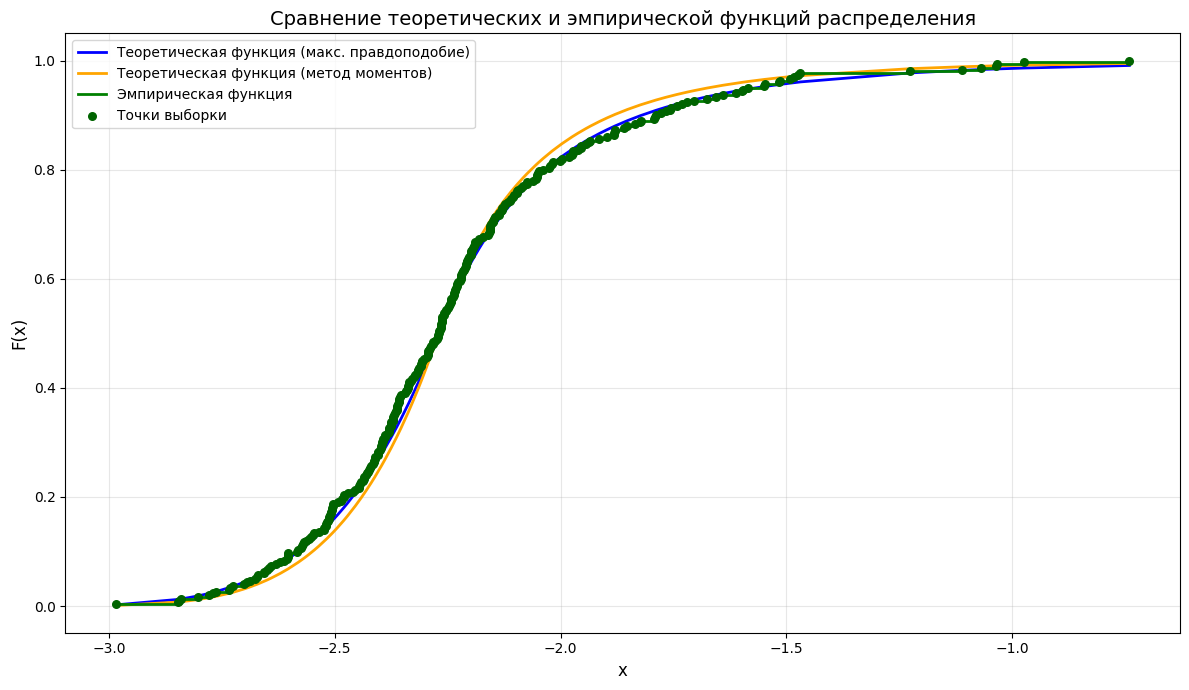

In [36]:
a, loc = find_loc_a_max_prav(selection)
a_2, loc_2 = find_loc_a_moment(selection)

x, y = teoretic(selection, loc, a)
x_2, y_2 = teoretic(selection, loc_2, a_2)

# Получаем эмпирическую функцию распределения
x_3, y_3 = ecdf(selection, selection_len)

# Создаем один график с тремя линиями
plt.figure(figsize=(12, 7))

# Теоретические функции
plt.plot(x, y, label="Теоретическая функция (макс. правдоподобие)", linewidth=2, color='blue')
plt.plot(x_2, y_2, label="Теоретическая функция (метод моментов)", linewidth=2, color='orange')

# Эмпирическая функция (ступенчатая)
plt.step(x_3, y_3, where='post', label="Эмпирическая функция", linewidth=2, color='green')

# Точки выборки
plt.scatter(x_3, y_3, label="Точки выборки", color='darkgreen', s=30, zorder=5)

plt.xlabel('x', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.title('Сравнение теоретических и эмпирической функций распределения', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Мера разброса оценки:

In [37]:
def se_a(a: float, n: float) -> float:
    return 1 / sqrt(n / a**2)

def se_loc(selection: list, loc: float, a: float) -> float:
    sum_min: float = 0
    sum_max: float = 0
    
    for elem in selection:
        if(elem - loc <= 1):
            sum_min += (1 - a) / (elem - loc)**2
        else:
            sum_max -= (a + 1) / (elem - loc)**2
    
    return 1 / sqrt(-(sum_min + sum_max))

def mera_spread(selection: list, a: float, loc: float, n: float, z: float) -> list:
    return [[round(a - z * se_a(a, n), 2), round(a + z * se_a(a, n), 2)], [round(loc - z * se_loc(selection, loc, a), 2), round(loc + z * se_loc(selection, loc, a), 2)]]

In [38]:
a, loc = find_loc_a_max_prav(selection)

z: float = 1.96
print(mera_spread(selection, a, loc, selection_len, z))
z: float = 2.576
print(mera_spread(selection, a, loc, selection_len, z))

[[3.84, 4.82], [-3.32, -3.22]]
[[3.69, 4.97], [-3.34, -3.2]]


Ошибки первого и второго рода:

In [46]:
def generate_loglaplace_sample(a: float, loc: float, n=1000):
    u = np.random.rand(n)

    x = np.where(
        u < 0.5,
        (2 * u) ** (1 / a),
        (2 * (1 - u)) ** (-1 / a)
    )

    return loc + x

def MLE(sample):
    y_min = min(sample)

    def neg_ll(params):
        a, loc = params

        if a <= 0.3:
            return 1e100
        if loc >= y_min - 1e-6:
            return 1e100

        return -func_pravdopodobie(sample, Point(a, loc))

    res = minimize(
        neg_ll,
        x0=[2.0, y_min - 0.1],
        bounds=[(0.3, None), (None, None)]
    )

    return res.x[0], res.x[1]

def lrt_test(sample, a0, loc0):
    a_hat, loc_hat = MLE(sample)

    ll1 = func_pravdopodobie(sample, Point(a_hat, loc_hat))
    ll0 = func_pravdopodobie(sample, Point(a0, loc0))

    stat = 2 * (ll1 - ll0)

    return stat, stat

def critical_value(a0, loc0, n=300, m=1000):
    stats = []

    for _ in range(m):
        sample = generate_loglaplace_sample(a0, loc0, n)
        stat, _ = lrt_test(sample, a0, loc0)
        stats.append(stat)

    return np.quantile(stats, 0.95)

def estimate_alpha(a0, loc0, n=300, m=1000):
    c = critical_value(a0, loc0, n, m)

    count = 0
    for _ in range(m):
        sample = generate_loglaplace_sample(a0, loc0, n)
        stat, _ = lrt_test(sample, a0, loc0)

        if stat > c:
            count += 1

    return count / m

def estimate_beta(a0, loc0, a1, loc1, n=300, m=1000):
    c = critical_value(a0, loc0, n, m)

    count = 0
    for _ in range(m):
        sample = generate_loglaplace_sample(a1, loc1, n)
        stat, _ = lrt_test(sample, a0, loc0)

        if stat <= c:
            count += 1

    return count / m

In [47]:
a0, loc0 = find_loc_a_moment(selection)
a1, loc1 = find_loc_a_max_prav(selection)

alpha: float = estimate_alpha(a0, loc0)
beta: float = estimate_beta(a0, loc0, a1, loc1)
alpha, beta

(0.058, 0.511)